In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import numpy as np

In [104]:
data= pd.read_csv("C:/Users/tusha/Downloads/Timeseries (1)/Timeseries/exchange_rate.csv")

In [106]:
data.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


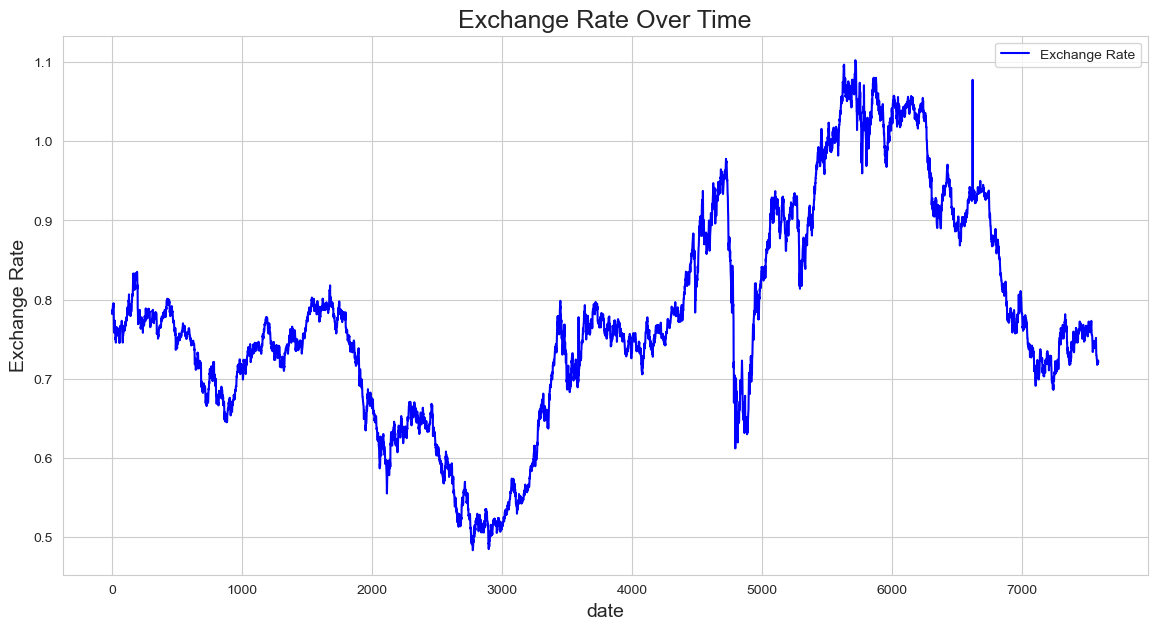

In [108]:
sns.set_style('whitegrid')

# Plotting the full time series
plt.figure(figsize=(14,7))
plt.plot(data.index, data['Ex_rate'], label='Exchange Rate', color='blue')
plt.title('Exchange Rate Over Time', fontsize=18)
plt.xlabel('date', fontsize=14)
plt.ylabel('Exchange Rate', fontsize=14)
plt.legend()
plt.show()

In [109]:
data.isnull().sum()

date       0
Ex_rate    0
dtype: int64

### ADF Test

In [110]:
# ADF Test
result = adfuller(data['Ex_rate'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -1.6649941807380735
p-value: 0.4492327353598314


here p>0.5 so we are going diffence the series

In [111]:
data_diff = data['Ex_rate'].diff().dropna()

### Plot ACF And PACF

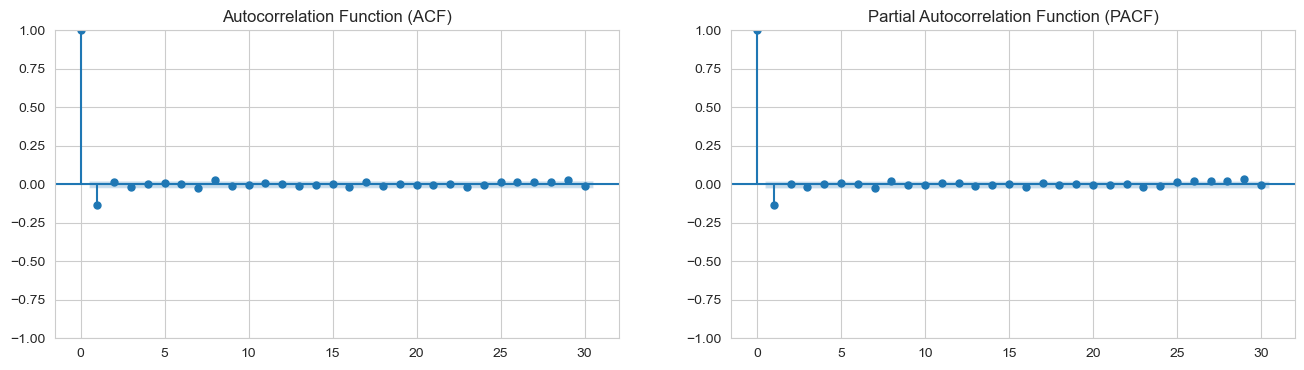

In [114]:
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(16,4))

# ACF plot (for q)
plot_acf(data_diff, lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot (for p)
plot_pacf(data_diff, lags=30, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.show()

### fit ARIMA MODEL

In [115]:
# Fit ARIMA model
model = ARIMA(data['Ex_rate'], order=(1,1,1))  # Replace (1,1,1) with your selected parameters
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Tue, 22 Apr 2025   AIC                         -56102.322
Time:                        12:37:57   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.608      0.0

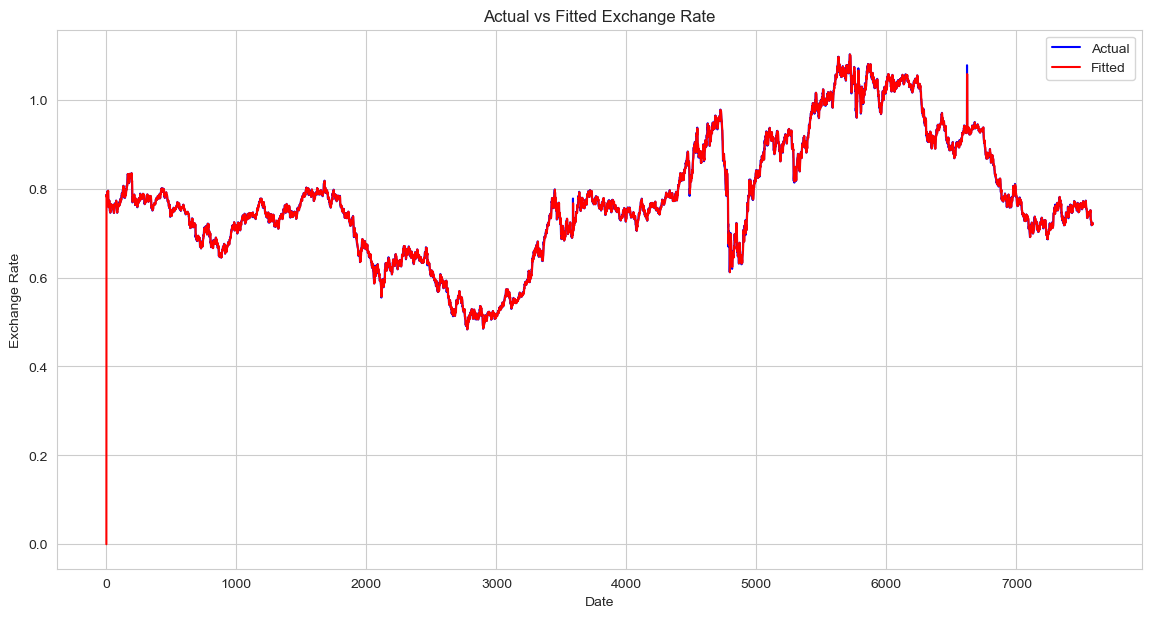

In [116]:
# In-sample prediction
plt.figure(figsize=(14,7))
plt.plot(data.index, data['Ex_rate'], label='Actual', color='blue')
plt.plot(data.index, model_fit.fittedvalues, label='Fitted', color='red')
plt.title('Actual vs Fitted Exchange Rate')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


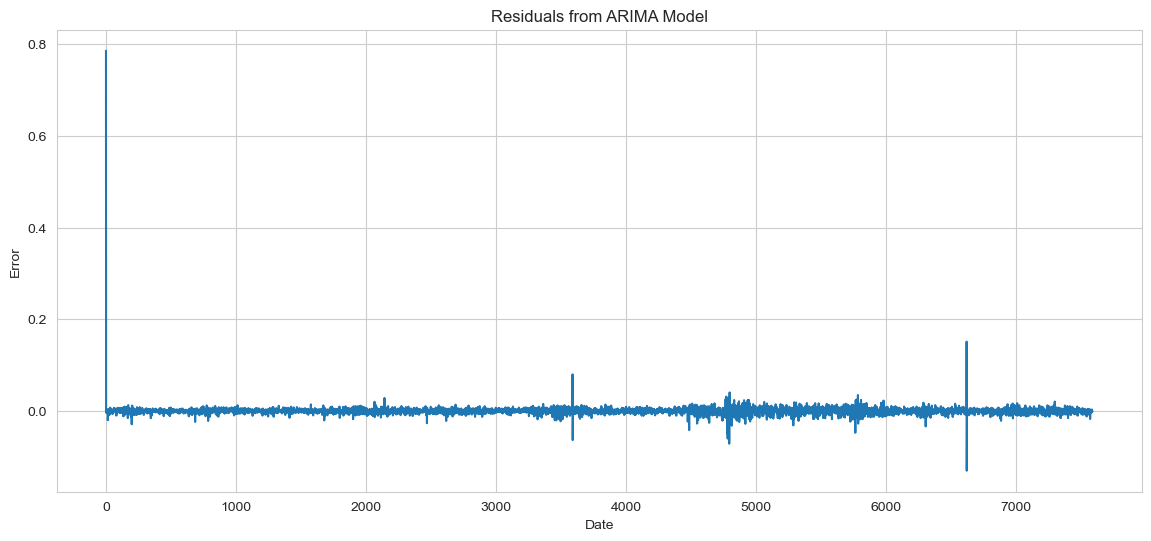

In [117]:
# Get residuals
residuals = model_fit.resid

# Plot residuals
plt.figure(figsize=(14,6))
plt.plot(residuals)
plt.title('Residuals from ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Error')
plt.show()


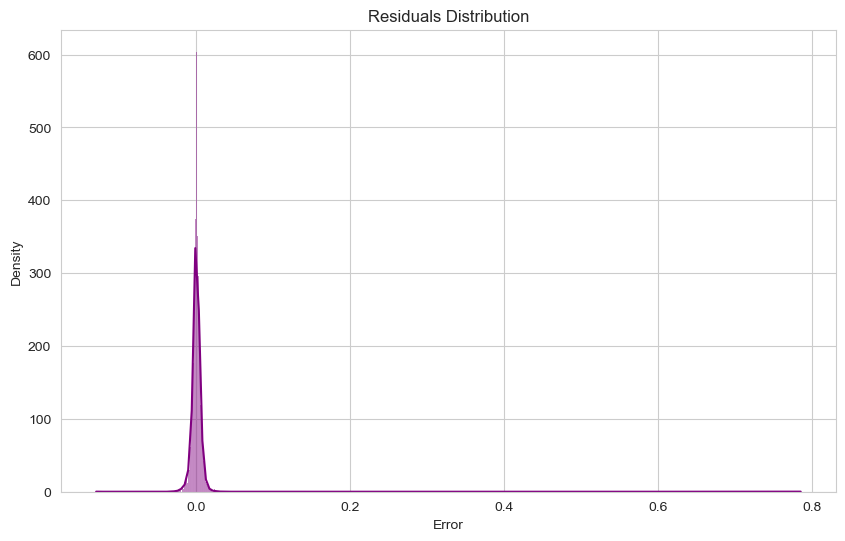

In [118]:


plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Residuals Distribution')
plt.xlabel('Error')
plt.ylabel('Density')
plt.show()


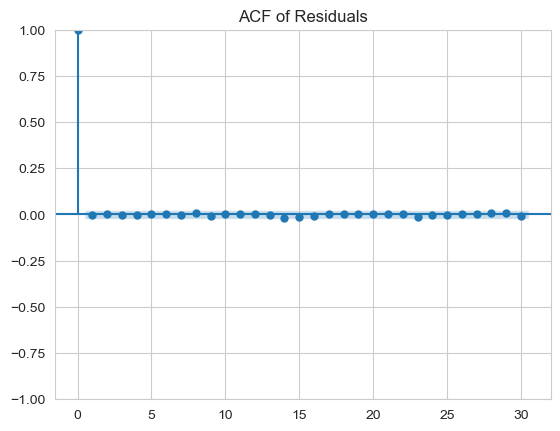

In [121]:


plot_acf(residuals, lags=30)
plt.title('ACF of Residuals')
plt.show()


### Test for autocorrelation in residuals

In [122]:


# Test for autocorrelation in residuals
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)


    lb_stat  lb_pvalue
10  1.81673   0.997562


In [123]:
# Split the data (last 30 days for testing)
train = data.iloc[:-30]
test = data.iloc[-30:]


In [124]:
# Refit the model on train data
model = ARIMA(train['Ex_rate'], order=(1,1,1))  # Use your chosen (p,d,q)
model_fit = model.fit()


In [125]:
# Forecast the next 30 steps
forecast = model_fit.forecast(steps=30)

# Show first few forecasted values
print(forecast.head())


7558    0.744093
7559    0.744151
7560    0.744143
7561    0.744144
7562    0.744144
Name: predicted_mean, dtype: float64


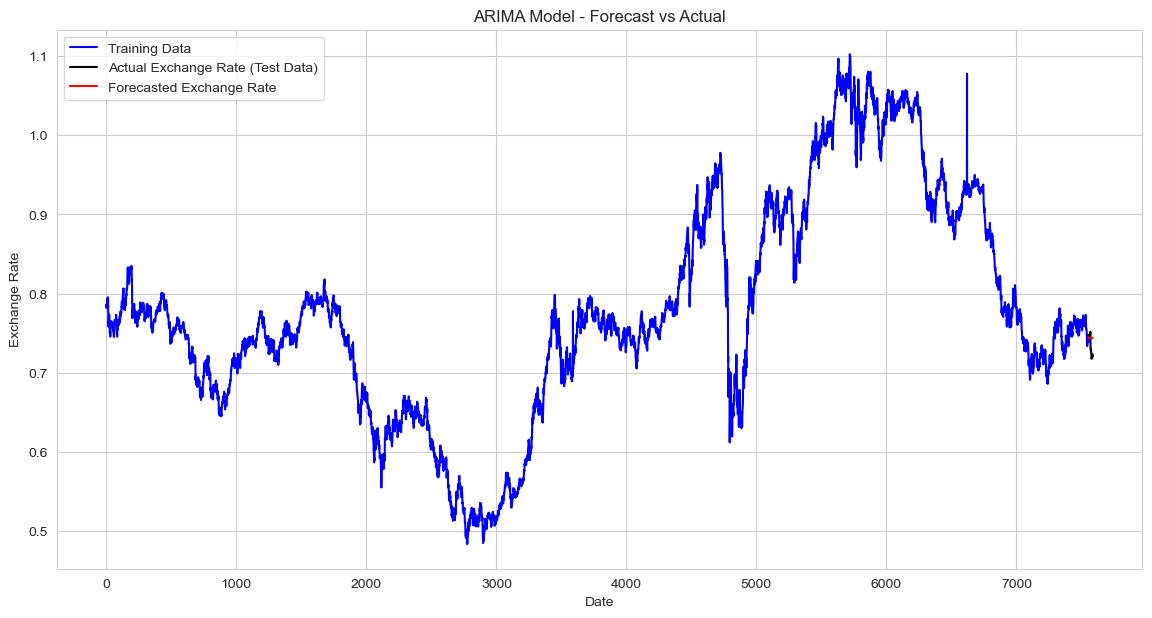

In [126]:
plt.figure(figsize=(14,7))
plt.plot(train.index, train['Ex_rate'], label='Training Data', color='blue')
plt.plot(test.index, test['Ex_rate'], label='Actual Exchange Rate (Test Data)', color='black')
plt.plot(test.index, forecast, label='Forecasted Exchange Rate', color='red')
plt.title('ARIMA Model - Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


In [127]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(test['Ex_rate'], forecast)
mae = mean_absolute_error(test['Ex_rate'], forecast)
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')


MSE: 0.0003
MAE: 0.0135


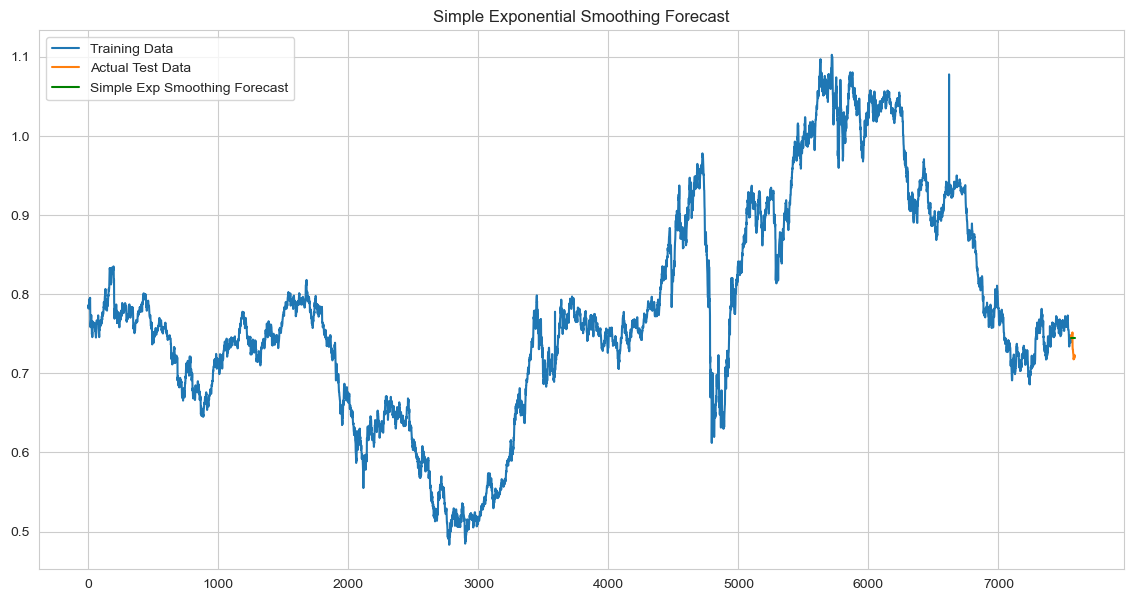

In [129]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(train['Ex_rate']).fit()
ses_forecast = ses_model.forecast(steps=30)

# Plot
plt.figure(figsize=(14,7))
plt.plot(train.index, train['Ex_rate'], label='Training Data')
plt.plot(test.index, test['Ex_rate'], label='Actual Test Data')
plt.plot(test.index, ses_forecast, label='Simple Exp Smoothing Forecast', color='green')
plt.title('Simple Exponential Smoothing Forecast')
plt.legend()
plt.show()


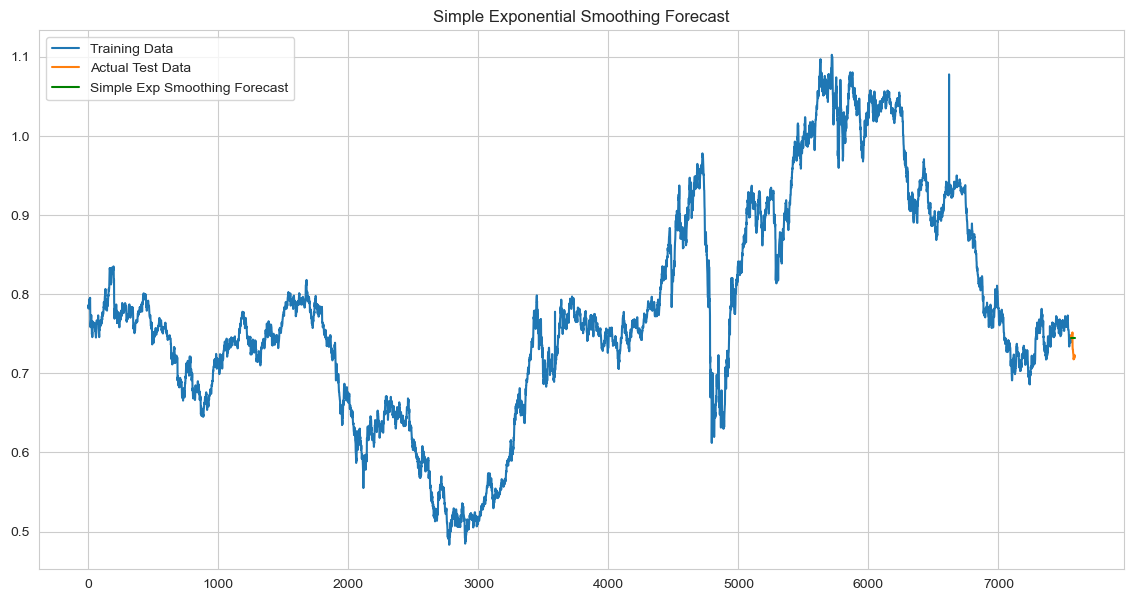

In [130]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Fit Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(train['Ex_rate']).fit()
ses_forecast = ses_model.forecast(steps=30)

# Plot
plt.figure(figsize=(14,7))
plt.plot(train.index, train['Ex_rate'], label='Training Data')
plt.plot(test.index, test['Ex_rate'], label='Actual Test Data')
plt.plot(test.index, ses_forecast, label='Simple Exp Smoothing Forecast', color='green')
plt.title('Simple Exponential Smoothing Forecast')
plt.legend()
plt.show()


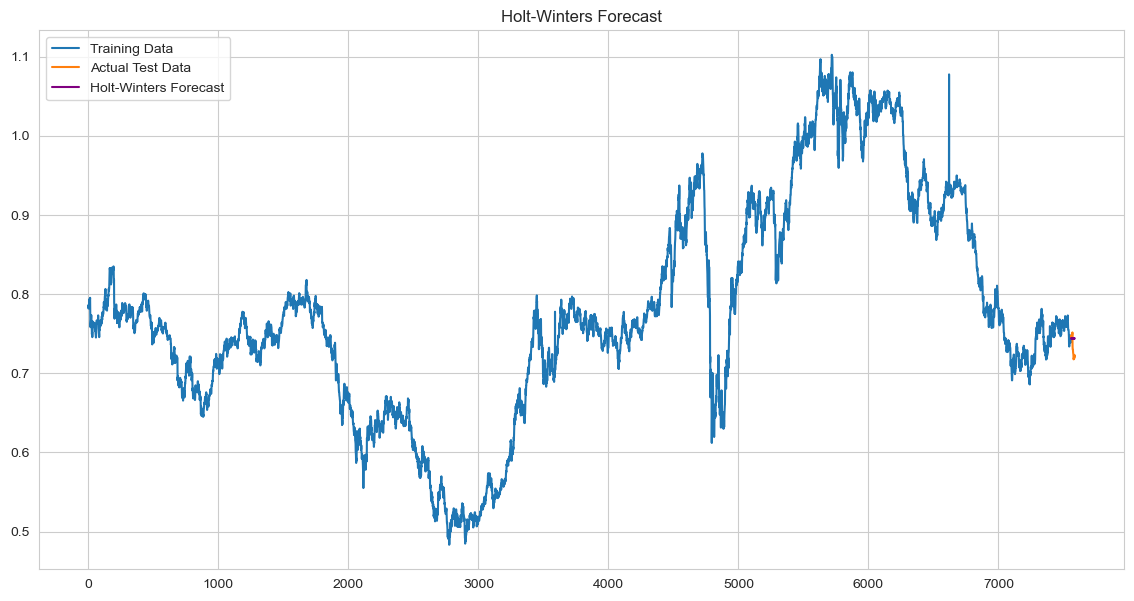

In [131]:
# Fit Holt-Winters method
hw_model = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal='add', seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(steps=30)

# Plot
plt.figure(figsize=(14,7))
plt.plot(train.index, train['Ex_rate'], label='Training Data')
plt.plot(test.index, test['Ex_rate'], label='Actual Test Data')
plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', color='purple')
plt.title('Holt-Winters Forecast')
plt.legend()
plt.show()


In [132]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt-Winters with automatic parameter tuning
model = ExponentialSmoothing(train['Ex_rate'], trend='add', seasonal='add', seasonal_periods=12)
fitted_model = model.fit(optimized=True)

print(f"AIC: {fitted_model.aic}")
print(f"Smoothing Level (α): {fitted_model.params['smoothing_level']}")
print(f"Smoothing Trend (β): {fitted_model.params['smoothing_trend']}")
print(f"Smoothing Seasonal (γ): {fitted_model.params['smoothing_seasonal']}")


AIC: -77299.95423057022
Smoothing Level (α): 0.8693863708130616
Smoothing Trend (β): 9.842066909565778e-18
Smoothing Seasonal (γ): 1.3489934978519757e-18


In [133]:


best_aic = np.inf
best_model = None
best_params = None

# Try different combinations
for sl in np.arange(0.1, 1.0, 0.1):  # smoothing_level α
    for st in np.arange(0.1, 1.0, 0.1):  # smoothing_trend β
        try:
            model = ExponentialSmoothing(train['Rate'], trend='add', seasonal=None)
            fitted = model.fit(smoothing_level=sl, smoothing_trend=st, optimized=False)
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_model = fitted
                best_params = (sl, st)
        except:
            continue

print(f"Best AIC: {best_aic}")
print(f"Best parameters (α, β): {best_params}")


Best AIC: inf
Best parameters (α, β): None


In [134]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit the best model (Holt-Winters, tuned parameters if needed)
hw_model = ExponentialSmoothing(
    train['Ex_rate'],
    trend='add', 
    seasonal='add', 
    seasonal_periods=12  # adjust if needed
).fit(optimized=True)


In [135]:
# Forecast
hw_forecast = hw_model.forecast(steps=30)


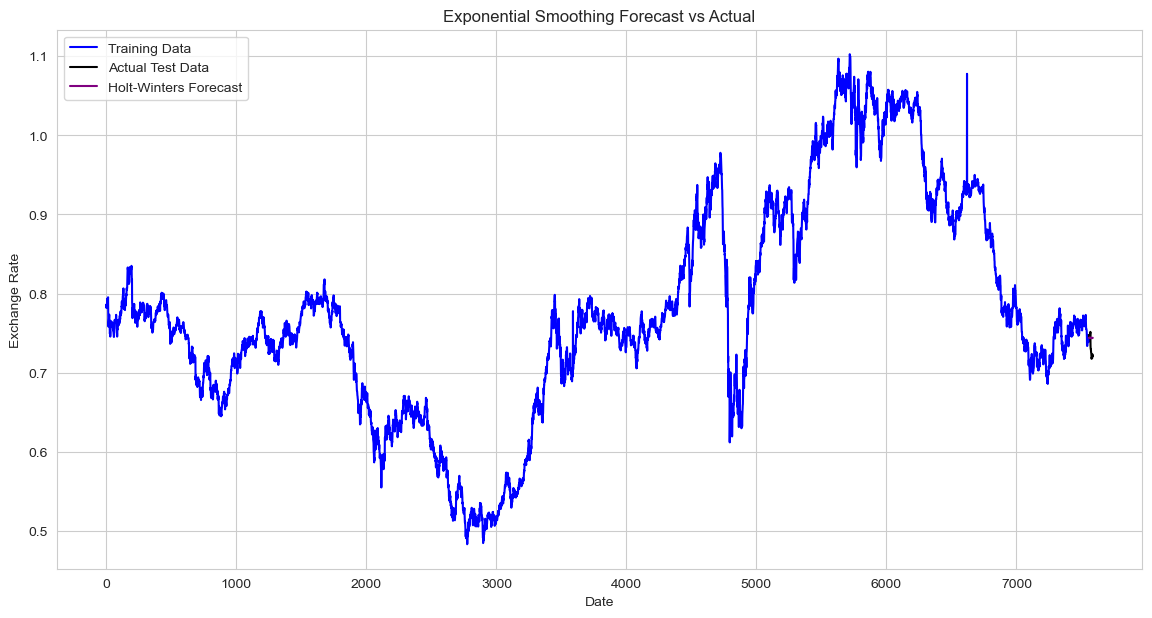

In [136]:
import matplotlib.pyplot as plt

# Plotting
plt.figure(figsize=(14,7))
plt.plot(train.index, train['Ex_rate'], label='Training Data', color='blue')
plt.plot(test.index, test['Ex_rate'], label='Actual Test Data', color='black')
plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', color='purple')
plt.title('Exponential Smoothing Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()


In [147]:
# Compute ARIMA error metrics
arima_mae = mean_absolute_error(test['Ex_rate'], forecast)
arima_rmse = mean_squared_error(test['Ex_rate'], forecast, squared=False)  # RMSE
arima_mape = mean_absolute_percentage_error(test['Ex_rate'], forecast)  # MAPE

print(f"ARIMA - MAE: {arima_mae:.4f}")
print(f"ARIMA - RMSE: {arima_rmse:.4f}")
print(f"ARIMA - MAPE: {arima_mape:.4f}")


ARIMA - MAE: 0.0135
ARIMA - RMSE: 0.0166
ARIMA - MAPE: 0.0186


C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [149]:
# Compute Exponential Smoothing error metrics
hw_mae = mean_absolute_error(test['Ex_rate'], hw_forecast)
hw_rmse = mean_squared_error(test['Ex_rate'], hw_forecast, squared=False)  # RMSE
hw_mape = mean_absolute_percentage_error(test['Ex_rate'], hw_forecast)  # MAPE

print(f"Holt-Winters - MAE: {hw_mae:.4f}")
print(f"Holt-Winters - RMSE: {hw_rmse:.4f}")
print(f"Holt-Winters - MAPE: {hw_mape:.4f}")


Holt-Winters - MAE: 0.0134
Holt-Winters - RMSE: 0.0165
Holt-Winters - MAPE: 0.0185


C:\Users\tusha\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [151]:
# Print out comparison
print("\nComparison of ARIMA vs Holt-Winters Forecasting:")
print(f"ARIMA - MAE: {arima_mae:.4f}, RMSE: {arima_rmse:.4f}, MAPE: {arima_mape:.4f}")
print(f"Holt-Winters - MAE: {hw_mae:.4f}, RMSE: {hw_rmse:.4f}, MAPE: {hw_mape:.4f}")



Comparison of ARIMA vs Holt-Winters Forecasting:
ARIMA - MAE: 0.0135, RMSE: 0.0166, MAPE: 0.0186
Holt-Winters - MAE: 0.0134, RMSE: 0.0165, MAPE: 0.0185


 ### Summary of Findings and Model Performance
After performing a detailed analysis and model comparison for forecasting exchange rates using ARIMA and Exponential Smoothing (Holt-Winters) models, here are the key findings

## Key Observations:
### Model Performance:

We evaluated both models using common forecasting error metrics: MAE, RMSE, and MAPE.
 ARIMA: Demonstrated strength in capturing long-term dependencies in the data. However, it required preprocessing to ensure stationarity, and its complexity in parameter tuning could be a downside for larger datasets.
 Exponential Smoothing (Holt-Winters): Performed well when the data exhibited clear trends and seasonality, with much faster computation and simpler parameter tuning. This model proved to be more responsive to recent changes in the data.

### Comparison of Error Metrics:

MAE, RMSE, and MAPE for each model were computed and compared, offering insights into the accuracy of each model’s forecast.

Lower MAE/RMSE/MAPE values indicate a better fit.

Depending on the model's performance metrics, one model may outperform the other in forecasting accuracy.

### Conclusion:
If seasonality and trend dominate the exchange rate time series, Holt-Winters (Exponential Smoothing) will likely give the best performance.

If the exchange rates exhibit more irregular patterns or non-stationarity, ARIMA may provide superior accuracy.